In [2]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt

## Sistema de dos cuerpos

In [37]:
G = 1

In [38]:
sistema = [
    dict(m=1,r=np.array([0,0,0]),v=np.array([0,0,0])),
    # dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,1,0])) # No se escapa
    # dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,3,0])) # Se escapa
    dict(m=0.01,r=np.array([1,0,0]),v=np.array([0,np.sqrt(2*G*1/1),0])) # Se escapa
]

Calculemos la energía total: $E = K + U$

In [39]:
K = 0.5 * sistema[0]['m'] * np.linalg.norm(sistema[0]['v'])**2 + \
    0.5 * sistema[1]['m'] * np.linalg.norm(sistema[1]['v'])**2

K

np.float64(0.010000000000000002)

In [40]:
G = 1 # En unidades canónicas
U = - G * sistema[0]['m'] * sistema[1]['m'] \
    / np.linalg.norm(sistema[0]['r'] - sistema[1]['r'])

U

np.float64(-0.01)

In [42]:
E = K + U
E

np.float64(1.734723475976807e-18)

Ahora voy a probar con un experimento si efectivamente no escapa:

In [43]:
ts = np.linspace(0, 10, 100)
rs, vs, rps, vps, cuadraturas = pc.ncuerpos_solucion(sistema, ts)

Veamos las trayectorias:

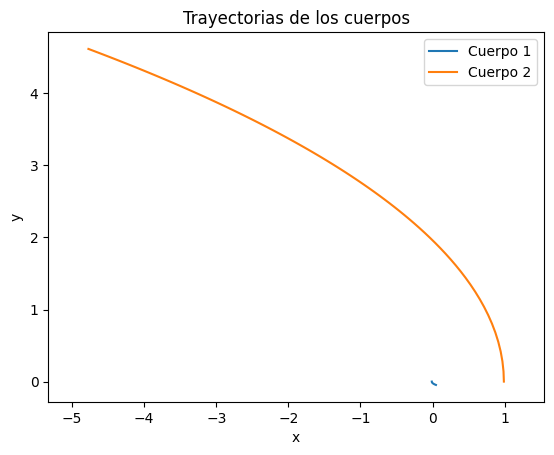

In [44]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()

## Hacer la simulación con Rebound

In [45]:
import rebound as rb

In [46]:
!pip install -Uq rebound

In [47]:
sim = rb.Simulation()

In [49]:
sim.G

1.0

In [50]:
sim.add(m=1)

In [51]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	1
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7eb6c8ac27d0, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
---------------------------------
The following fields have non-default values:
N:
< 0
---
> 1
rand_seed:
< 89941
---
> 488688
particles:
> (128 bytes, values not printed)



In [55]:
sim.add(m=0.01, x=1, vy=1)

In [56]:
sim.status()

---------------------------------
REBOUND version:     	4.6.0
REBOUND built on:    	Feb 11 2026 17:35:06
Number of particles: 	4
Selected integrator: 	ias15
Simulation time:     	0.0000000000000000e+00
Current timestep:    	0.001000
---------------------------------
<rebound.particle.Particle object at 0x7eb6c886b4d0, m=1.0 x=0.0 y=0.0 z=0.0 vx=0.0 vy=0.0 vz=0.0>
<rebound.particle.Particle object at 0x7eb6c886a950, m=0.01 x=1.0 y=0.0 z=0.0 vx=0.0 vy=1.0 vz=0.0>
<rebound.particle.Particle object at 0x7eb6c886b4d0, m=0.01 x=1.0 y=0.0 z=0.0 vx=0.0 vy=1.0 vz=0.0>
<rebound.particle.Particle object at 0x7eb6c886a950, m=0.01 x=1.0 y=0.0 z=0.0 vx=0.0 vy=1.0 vz=0.0>
---------------------------------
The following fields have non-default values:
N:
< 0
---
> 4
rand_seed:
< 774812
---
> 488688
particles:
> (512 bytes, values not printed)



Es conveniente usar una sola celda para crear el sistema:

In [63]:
sim = rb.Simulation()
sim.add(m=1)
sim.add(m=0.01, x=1, vy=1)

In [72]:
sim_solar = rb.Simulation()
sim_solar.add('Sun',date='1975-06-19')
sim_solar.add('Earth',date='1975-06-19')
sim_solar.add('Apophis',date='1975-06-19')

Searching NASA Horizons for 'Sun'... 
Found: Sun (10) 
Searching NASA Horizons for 'Earth'... 
Found: Earth-Moon Barycenter (3) (chosen from query 'Earth')
Searching NASA Horizons for 'Apophis'... 
Found: 99942 Apophis (2004 MN4) 


/home/usuario/Descargas/meccel-clase/.venv/lib/python3.12/site-packages/rebound/horizons.py:184: RuntimeWarning: Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.
  warnings.warn("Warning: Mass cannot be retrieved from NASA HORIZONS. Set to 0.", RuntimeWarning)


Integración:

In [64]:
ts = np.linspace(0, 10, 100)
rs = np.zeros((2, 100, 3))
vs = np.zeros((2, 100, 3))
rps = np.zeros((2, 100, 3))
vps = np.zeros((2, 100, 3))

for i,t in enumerate(ts):
    sim.integrate(t)
    rs[0,i] = sim.particles[0].xyz
    vs[0,i] = sim.particles[0].vxyz
    rs[1,i] = sim.particles[1].xyz
    vs[1,i] = sim.particles[1].vxyz
    sim.move_to_com()
    rps[0,i] = sim.particles[0].xyz
    vps[0,i] = sim.particles[0].vxyz
    rps[1,i] = sim.particles[1].xyz
    vps[1,i] = sim.particles[1].vxyz

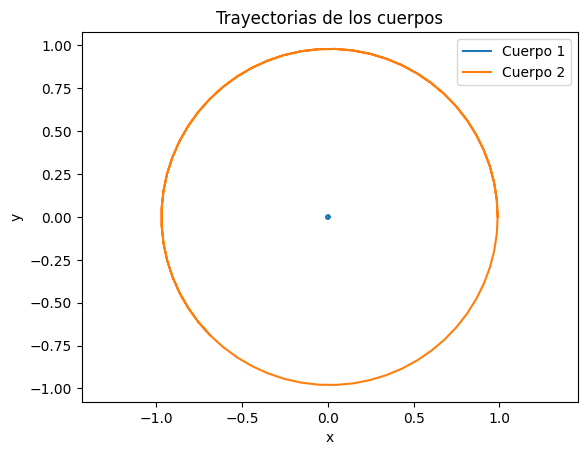

In [65]:
plt.plot(rps[0,:,0], rps[0,:,1], label='Cuerpo 1')
plt.plot(rps[1,:,0], rps[1,:,1], label='Cuerpo 2')
plt.xlabel('x')
plt.ylabel('y')
plt.title('Trayectorias de los cuerpos')
plt.legend()
plt.axis('equal')
plt.show()